# EEOF analysis of CHIRPS precipitation over the Greater Horn of Africa

This notebook performs an **Extended Empirical Orthogonal Function (EEOF)** decomposition of monthly precipitation anomalies from CHIRPS v3 (0.5°, 1981–2025) over the Greater Horn of Africa.

Pipeline:
1. Load the CHIRPS monthly precipitation field.
2. Remove the seasonal cycle by harmonic regression (4 harmonics).
3. Build a time-lag augmented matrix and decompose its covariance via EOF.
4. Wrap the eigenvalues, eigenvectors, EEOF spatial patterns and variance explained as `xarray` DataArrays / Datasets.
5. Visualize the leading modes, their PC time series, and their cross-correlations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy import linalg as la

## Helper functions

In [2]:
def remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=12):
    """
    Remove seasonal cycle using harmonic regression.

    Parameters
    ----------
    data : ndarray
        3D array with shape (time, lat, lon). No NaN values.
    n_harmonics : int
        Number of harmonic pairs (sin/cos) to fit (default: 4).
    year_period : float
        Period of the seasonal cycle in time units (default: 12 months).

    Returns
    -------
    anomalies : ndarray
        Data with seasonal cycle removed, same shape as input.
    """
    n_time, n_lat, n_lon = data.shape
    data_2d = data.reshape(n_time, -1)

    # Build design matrix: 1 constant + n_harmonics sin/cos pairs
    t = np.arange(n_time)
    X = np.ones((n_time, 2 * n_harmonics + 1))
    for i in range(1, n_harmonics + 1):
        X[:, 2*i - 1] = np.sin(i * 2 * np.pi * t / year_period)
        X[:, 2*i] = np.cos(i * 2 * np.pi * t / year_period)

    # Solve via least squares and subtract seasonal component
    coeffs = np.linalg.lstsq(X, data_2d, rcond=None)[0]
    anomalies = data_2d - X @ coeffs

    return anomalies.reshape(n_time, n_lat, n_lon)

In [3]:
def build_lagged_matrix(data_matrix, max_lag):
    '''
    Build the time-lag augmented matrix used for Extended EOF analysis.

    Given a 2D (time, space) matrix, this returns a matrix where each row
    contains the original spatial map concatenated with its lagged copies,
    so the resulting shape is (time - max_lag, space * (max_lag + 1)).
    '''
    n_time, n_space = data_matrix.shape

    lagged_matrix = np.zeros((n_time - max_lag, n_space * (max_lag + 1))) * np.nan

    for i in range(max_lag + 1):
        if (max_lag - i) != 0:
            lagged_matrix[:, i*n_space: i*n_space + n_space] = data_matrix[i:i - max_lag, :]
        else:
            lagged_matrix[:, i*n_space: i*n_space + n_space] = data_matrix[i:, :]

    return lagged_matrix

In [4]:
def compute_eeof(data_3d, data_matrix, max_lag):
    """
    Compute Time-Extended Empirical Orthogonal Functions (EEOF).

    Parameters
    ----------
    data_3d : ndarray
        Original 3D data array with shape (time, lat, lon). Used only to
        recover the spatial shape when reshaping the EOFs.
    data_matrix : ndarray
        2D (time, space) matrix obtained by reshaping `data_3d`.
    max_lag : int
        Maximum lag (in time steps) used to build the augmented matrix.
        The number of lag blocks is `max_lag + 1`.

    Returns
    -------
    eigenvalues : ndarray
        Eigenvalues of the covariance matrix.
    eigenvectors : ndarray
        Eigenvectors (principal components in time) of the covariance matrix.
    eeof_reshaped : ndarray
        EEOF spatial patterns with shape (max_lag + 1, n_modes, lat, lon).
    variance_explained : ndarray
        Percentage of variance explained by each oscillation mode.
    """
    lagged_matrix = build_lagged_matrix(data_matrix, max_lag)

    nan_indices = np.where(np.isnan(lagged_matrix[0]))
    lagged_matrix_no_nan = np.delete(lagged_matrix, nan_indices, 1)

    cov_matrix = np.dot(lagged_matrix_no_nan, lagged_matrix_no_nan.T)
    eigenvalues, eigenvectors = la.eig(cov_matrix)

    total_variance = np.sum(eigenvalues)
    variance_explained = (eigenvalues / total_variance) * 100

    # Project eigenvectors onto the data to obtain the EOF spatial patterns
    eof_modes = np.dot(eigenvectors.T, lagged_matrix_no_nan)

    eof_with_nan = np.copy(lagged_matrix) * np.nan
    all_space_indices = np.arange(lagged_matrix.shape[1])
    valid_indices = np.setdiff1d(all_space_indices, nan_indices)
    eof_with_nan[:, valid_indices] = eof_modes
    eof_modes = eof_with_nan

    n_modes, n_space_total = eof_modes.shape
    eeof_reshaped = [np.copy(data_3d) * np.nan] * (max_lag + 1)

    # Split the EOF matrix into its lag blocks
    n_space_per_lag = int(n_space_total / (max_lag + 1))
    eof_split = np.zeros((max_lag + 1, n_modes, n_space_per_lag)) * np.nan

    for i in range(max_lag + 1):
        eof_split[i, :, :] = eof_modes[:, i*n_space_per_lag: (i + 1)*n_space_per_lag]

    for i in range(max_lag + 1):
        eeof_reshaped[i] = eof_split[i, :, :].reshape(
            data_3d.shape[0] - max_lag, data_3d.shape[1], data_3d.shape[2])

    eeof_reshaped = np.array(eeof_reshaped)

    return eigenvalues, eigenvectors, eeof_reshaped, variance_explained

## Load CHIRPS data and compute anomalies

In [5]:
file = 'CHIRPS_v3_GHA_monthly_0p5_1981-2025.nc'

ds = xr.open_dataset(file)
data = ds['precip'].values

# Compute anomalies by removing the seasonal cycle
anomalies = remove_seasonal_cycle_harmonic(data, n_harmonics=4, year_period=12)

# Wrap the anomalies as a DataArray
precip_anomalies_da = ds['precip'].copy(data=anomalies)
precip_anomalies_da.attrs['long_name'] += ' anomalies'
precip_anomalies_da

<xarray.DataArray 'precip' (time: 540, lat: 67, lon: 59)> Size: 17MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat      (lat) float32 268B -11.25 -10.75 -10.25 -9.75 ... 20.75 21.25 21.75
  * lon      (lon) float32 236B 22.25 22.75 23.25 23.75 ... 50.25 50.75 51.25
  * time     (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2025-12-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards center InfraRed Precipitation with S...
    time_step:           month
    geostatial_lat_min:  -60
    geostatial_lat_max:  60
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0

## Run the EEOF decomposition

We use a maximum lag of 12 months, so the augmented matrix contains 13 lag blocks (lags 0 through 12).

In [6]:
MAX_LAG = 12

n_time, n_lat, n_lon = anomalies.shape
data_matrix = anomalies.reshape(n_time, n_lat * n_lon)
print(f"data_matrix   shape: (time={data_matrix.shape[0]}, space={data_matrix.shape[1]})")

lagged_matrix = build_lagged_matrix(data_matrix, MAX_LAG)
print(f"lagged_matrix shape: (time={lagged_matrix.shape[0]}, space={lagged_matrix.shape[1]})")

eigenvalues, eigenvectors, eeofs, variance_explained = compute_eeof(
    anomalies, data_matrix, MAX_LAG
)

data_matrix   shape: (time=540, space=3953)
lagged_matrix shape: (time=528, space=51389)


## Wrap the outputs as `xarray` DataArrays

In [7]:
n_lag, n_modes, _, _ = eeofs.shape
eeof_coords = {
    'lag': np.arange(MAX_LAG + 1),
    'mode': np.arange(n_modes),
    'lat': ds.lat.values,
    'lon': ds.lon.values,
}
eeof_da = xr.DataArray(
    eeofs.astype('float32'),
    coords=eeof_coords,
    name='eof',
    attrs={'standard_name': 'EEOF'},
)
eeof_da

<xarray.DataArray 'eof' (lag: 13, mode: 528, lat: 67, lon: 59)> Size: 109MB
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]], dtype=float32)
Coordinates:
  * lag      (lag) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * mode     (mode) int64 4kB 0 1 2 3 4 5 6 7 ... 521 522 523 524 525 526 527
  * lat      (lat) float32 268B -11.25 -10.75 -10.25 -9.75 ... 20.75 21.25 21.75
  * lon      (lon) float32 236B 22.25 22.75 23.25 23.75 ... 50.25 50.75 51.25
Attributes:
    standard_name:  EEOF

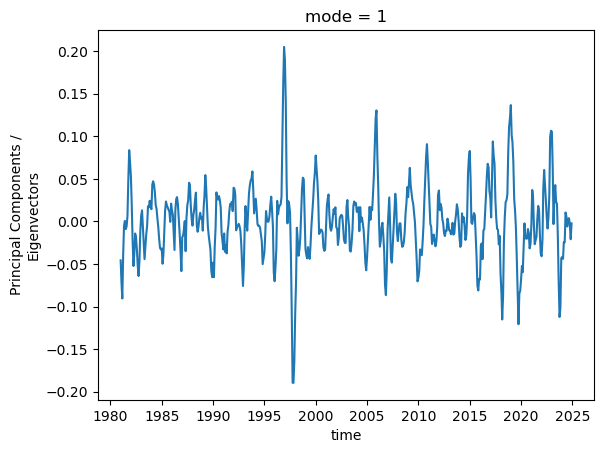

In [8]:
pc_coords = {
    'mode': np.arange(n_time - MAX_LAG),
    'time': ds.time.values[0:-MAX_LAG],
}
pcs_da = xr.DataArray(
    eigenvectors.T.astype('float32'),
    coords=pc_coords,
    name='pc',
    attrs={'standard_name': 'Principal Components / Eigenvectors'},
)
pcs_da[1].plot();

/tmp/ipykernel_2874842/1615935188.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  variance_explained.astype('float32'),


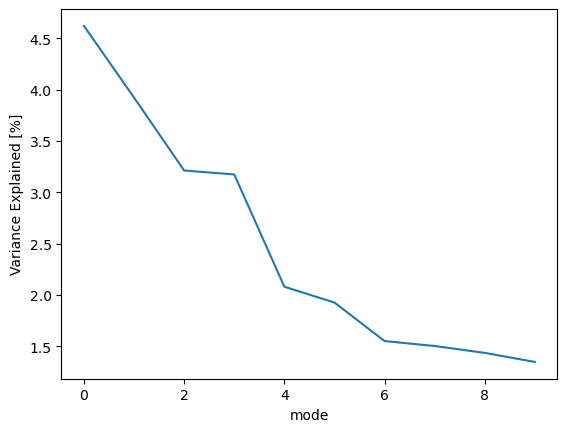

In [9]:
variance_explained_coords = {
    'mode': np.arange(len(variance_explained)),
}
variance_explained_da = xr.DataArray(
    variance_explained.astype('float32'),
    coords=variance_explained_coords,
    name='var_exp',
    attrs={'standard_name': 'Variance Explained [%]'},
)
variance_explained_da[:10].plot();

/tmp/ipykernel_2874842/2058055328.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  eigenvalues.astype('float32'),


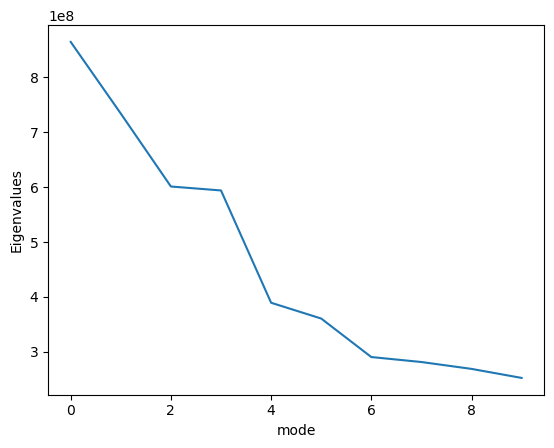

In [10]:
eigenvalues_coords = {
    'mode': np.arange(len(eigenvalues)),
}
eigenvalues_da = xr.DataArray(
    eigenvalues.astype('float32'),
    coords=eigenvalues_coords,
    name='eigenvalue',
    attrs={'standard_name': 'Eigenvalues'},
)
eigenvalues_da[:10].plot();

## Bundle everything into a single `Dataset` with metadata

In [11]:
ds_out = xr.Dataset({
    'eof': eeof_da,
    'pc': pcs_da,
    'eigenvalue': eigenvalues_da,
    'var_exp': variance_explained_da,
})

ds_out.attrs['analysis'] = 'EEOF of CHIRPS monthly precipitation anomalies'
ds_out.attrs['field'] = 'precipitation'
ds_out.attrs['source_file'] = file
ds_out.attrs['region'] = 'Greater Horn of Africa (GHA)'
ds_out.attrs['temporal_resolution'] = 'monthly'
ds_out.attrs['time_period'] = (
    f"{np.datetime_as_string(ds.time.values[0], unit='M')} to "
    f"{np.datetime_as_string(ds.time.values[-1], unit='M')}"
)
ds_out.attrs['anomaly_definition'] = (
    'seasonal cycle removed via harmonic regression '
    '(n_harmonics=4, year_period=12 months)'
)
ds_out.attrs['max_lag'] = f'{MAX_LAG} months'
ds_out.attrs['n_lag_blocks'] = int(MAX_LAG + 1)
ds_out.attrs['n_modes'] = int(n_modes)

# Uncomment to save to disk:
# ds_out.to_netcdf('chirps_eeof.nc')

ds_out

<xarray.Dataset> Size: 110MB
Dimensions:     (lag: 13, mode: 528, lat: 67, lon: 59, time: 528)
Coordinates:
  * lag         (lag) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * mode        (mode) int64 4kB 0 1 2 3 4 5 6 7 ... 521 522 523 524 525 526 527
  * lat         (lat) float32 268B -11.25 -10.75 -10.25 ... 20.75 21.25 21.75
  * lon         (lon) float32 236B 22.25 22.75 23.25 23.75 ... 50.25 50.75 51.25
  * time        (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2024-12-01
Data variables:
    eof         (lag, mode, lat, lon) float32 109MB nan nan nan ... nan nan nan
    pc          (mode, time) float32 1MB -0.04622 -0.03875 ... 0.03593 0.02131
    eigenvalue  (mode) float32 2kB 8.646e+08 7.34e+08 ... 8.612e+06 8.787e+06
    var_exp     (mode) float32 2kB 4.62 3.922 3.212 ... 0.04615 0.04602 0.04696
Attributes:
    analysis:             EEOF of CHIRPS monthly precipitation anomalies
    field:                precipitation
    source_file:          CHIRPS_v3_GHA_monthly_0p5_1981-2025.nc
    region:               Greater Horn of Africa (GHA)
    temporal_resolution:  monthly
    time_period:          1981-01 to 2025-12
    anomaly_definition:   seasonal cycle removed via harmonic regression (n_h...
    max_lag:              12 months
    n_lag_blocks:         13
    n_modes:              528

## Variance explained by the leading modes

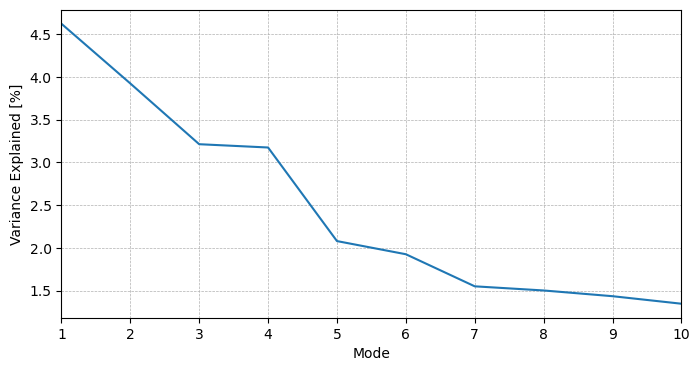

In [12]:
mode_list = np.arange(1, 11)
plt.figure(figsize=(8, 4))
plt.plot(mode_list, ds_out.var_exp[:len(mode_list)])
plt.xlabel('Mode')
plt.ylabel('Variance Explained [%]')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xlim(1, 10);

## EEOF spatial patterns

Each column is an EOF mode and each row is a different lag (in months).

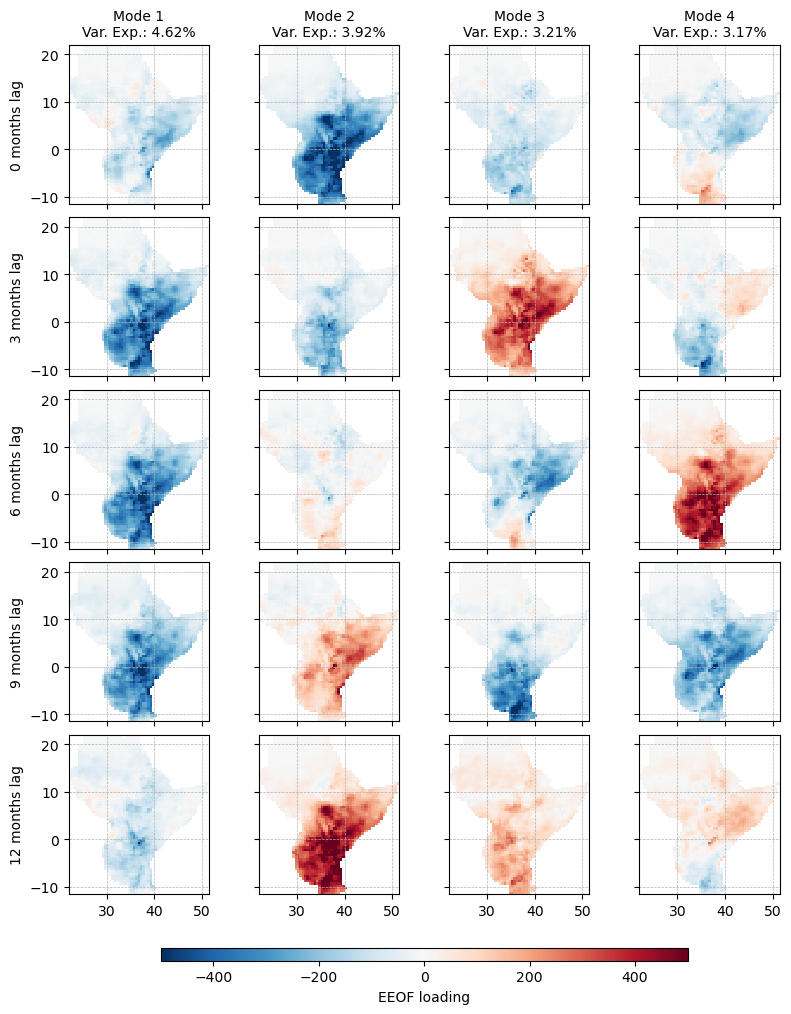

In [13]:
lag_list = np.arange(0, MAX_LAG + 1, 3)
n_modes_plot = 4
fig, ax = plt.subplots(
    figsize=(8, 10), ncols=n_modes_plot, nrows=len(lag_list),
    sharex=True, sharey=True, layout='constrained',
)

max_level = 500
cmap = 'RdBu_r'
lat_values = ds.lat.values
lon_values = ds.lon.values

for i, lag in enumerate(lag_list):
    for j, mode in enumerate(range(n_modes_plot)):
        ax[i, j].pcolormesh(
            lon_values, lat_values, ds_out.eof.sel(lag=lag, mode=mode),
            cmap=cmap, vmin=-max_level, vmax=max_level,
        )
        ax[i, j].set_aspect('equal')
        ax[i, j].grid(True, linestyle='--', linewidth=0.5)
        if i == 0:
            ax[i, j].set_title(
                f'Mode {mode+1}\nVar. Exp.: {variance_explained_da.sel(mode=mode).values:.2f}%',
                fontsize=10,
            )
        if j == 0:
            ax[i, j].set_ylabel(f'{lag} months lag')

cbar = fig.colorbar(
    ax[0, -1].collections[0],
    ax=ax,
    location='bottom',
    shrink=0.7,
    pad=0.03,
    aspect=40,
)
cbar.set_label('EEOF loading')
plt.show()

## Principal component time series

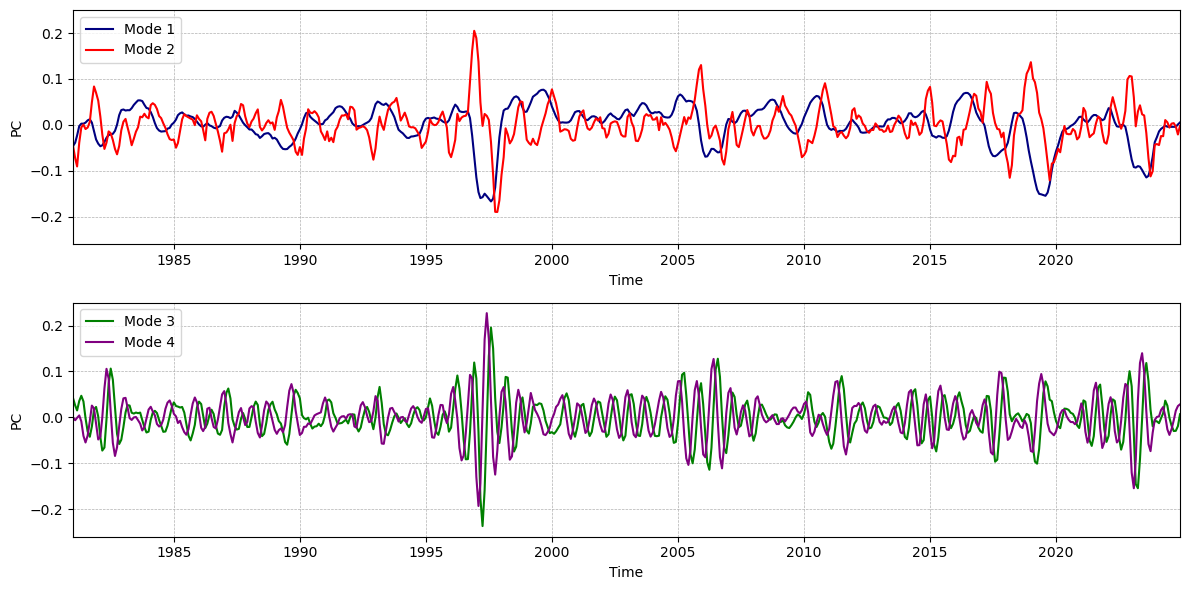

In [14]:
fig, ax = plt.subplots(figsize=(12, 6), ncols=1, nrows=2, sharey=True)

ax[0].plot(ds_out.time, ds_out.pc.sel(mode=0), label='Mode 1', color='navy')
ax[0].plot(ds_out.time, ds_out.pc.sel(mode=1), label='Mode 2', color='red')
ax[0].legend(loc='upper left')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('PC')
ax[0].set_xlim(ds_out.time.values[0], ds_out.time.values[-1])
ax[0].grid(True, linestyle='--', linewidth=0.5)

ax[1].plot(ds_out.time, ds_out.pc.sel(mode=2), label='Mode 3', color='green')
ax[1].plot(ds_out.time, ds_out.pc.sel(mode=3), label='Mode 4', color='purple')
ax[1].legend(loc='upper left')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('PC')
ax[1].set_xlim(ds_out.time.values[0], ds_out.time.values[-1])
ax[1].grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Phase-space scatter plots of PC pairs

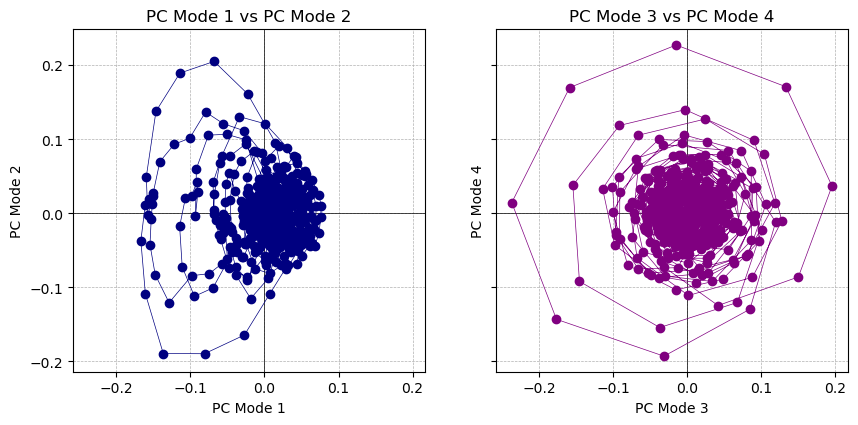

In [15]:
fig, ax = plt.subplots(figsize=(10, 6), ncols=2, nrows=1, sharex=True, sharey=True)

ax[0].set_title('PC Mode 1 vs PC Mode 2')
ax[0].axhline(0, color='black', linewidth=0.5)
ax[0].axvline(0, color='black', linewidth=0.5)
ax[0].plot(ds_out.pc.sel(mode=0), ds_out.pc.sel(mode=1),
           marker='o', linewidth=0.5, color='navy')
ax[0].set_xlabel('PC Mode 1')
ax[0].set_ylabel('PC Mode 2')
ax[0].grid(True, linestyle='--', linewidth=0.5)
ax[0].set_aspect('equal')

ax[1].set_title('PC Mode 3 vs PC Mode 4')
ax[1].axhline(0, color='black', linewidth=0.5)
ax[1].axvline(0, color='black', linewidth=0.5)
ax[1].plot(ds_out.pc.sel(mode=2), ds_out.pc.sel(mode=3),
           marker='o', linewidth=0.5, color='purple')
ax[1].set_xlabel('PC Mode 3')
ax[1].set_ylabel('PC Mode 4')
ax[1].grid(True, linestyle='--', linewidth=0.5)
ax[1].set_aspect('equal')

plt.show()

## Cross-correlation between PC pairs

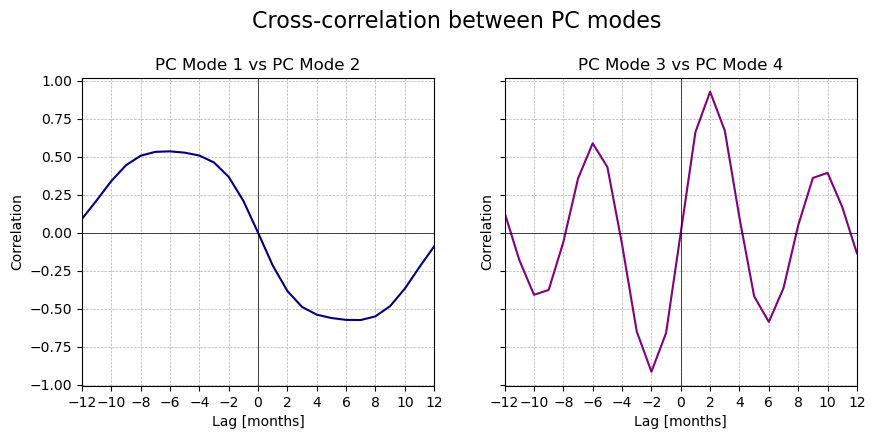

In [16]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharex=True, sharey=True)

ax[0].xcorr(ds_out.pc.sel(mode=0), ds_out.pc.sel(mode=1),
            maxlags=12, usevlines=False, linestyle='-', marker=None, color='navy')
ax[0].set_xlabel('Lag [months]')
ax[0].set_ylabel('Correlation')
ax[0].grid(True, linestyle='--', linewidth=0.5)
ax[0].set_xlim(-12, 12)
ax[0].set_xticks(np.arange(-12, 13, 2))
ax[0].set_title('PC Mode 1 vs PC Mode 2')
ax[0].axhline(0, color='black', linewidth=0.5)
ax[0].axvline(0, color='black', linewidth=0.5)

ax[1].xcorr(ds_out.pc.sel(mode=2), ds_out.pc.sel(mode=3),
            maxlags=12, usevlines=False, linestyle='-', marker=None, color='purple')
ax[1].set_xlabel('Lag [months]')
ax[1].set_ylabel('Correlation')
ax[1].grid(True, linestyle='--', linewidth=0.5)
ax[1].set_xlim(-12, 12)
ax[1].set_xticks(np.arange(-12, 13, 2))
ax[1].set_title('PC Mode 3 vs PC Mode 4')
ax[1].axhline(0, color='black', linewidth=0.5)
ax[1].axvline(0, color='black', linewidth=0.5)

fig.suptitle('Cross-correlation between PC modes', fontsize=16, y=1.05)
plt.show()